# Neural Networks with PyTorch

In this assignment, we are going to train a Neural Networks on the Japanese MNIST dataset. It is composed of 70000 images of handwritten Hiragana characters. The target variables has 10 different classes.

Each image is of dimension 28 by 28. But we will flatten them to form a dataset composed of vectors of dimension (784, 1). The training process will be similar as for a structured dataset.

Your goal is to run at least 3 experiments and get a model that can achieve 80% accuracy with not much overfitting on this dataset.

Note: You can only use fully-connected and dropout layers for this assignment. You can not convolution layers for instance

# 1. Import Required Packages

[1.1] We are going to use numpy, matplotlib and google.colab packages

In [54]:
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt

# 2. Download Dataset

We will store the dataset into your personal Google Drive.


[2.1] Mount Google Drive

In [55]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


[2.2] Create a folder called `DL_ASG_1` on your Google Drive at the root level

In [56]:
! mkdir -p /content/gdrive/MyDrive/DL_ASG_1

[2.3] Navigate to this folder

In [57]:
%cd '/content/gdrive/MyDrive/DL_ASG_1'

/content/gdrive/MyDrive/DL_ASG_1


[2.4] Show the list of item on the folder

In [58]:
!ls

first_model.pth   kmnist-test-imgs.npz	  kmnist-train-imgs.npz    second_model.pth
fourth_model.pth  kmnist-test-labels.npz  kmnist-train-labels.npz  third_model.pth


[2.4] Dowload the dataset files to your Google Drive if required

In [59]:
import requests
from tqdm import tqdm
import os.path

def download_file(url):
    path = url.split('/')[-1]
    if os.path.isfile(path):
        print (f"{path} already exists")
    else:
      r = requests.get(url, stream=True)
      with open(path, 'wb') as f:
          total_length = int(r.headers.get('content-length'))
          print('Downloading {} - {:.1f} MB'.format(path, (total_length / 1024000)))
          for chunk in tqdm(r.iter_content(chunk_size=1024), total=int(total_length / 1024) + 1, unit="KB"):
              if chunk:
                  f.write(chunk)

url_list = [
    'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-train-imgs.npz',
    'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-train-labels.npz',
    'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-test-imgs.npz',
    'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-test-labels.npz'
]

for url in url_list:
    download_file(url)

kmnist-train-imgs.npz already exists
kmnist-train-labels.npz already exists
kmnist-test-imgs.npz already exists
kmnist-test-labels.npz already exists


[2.5] List the content of the folder and confirm files have been dowloaded properly

In [60]:
! ls

first_model.pth   kmnist-test-imgs.npz	  kmnist-train-imgs.npz    second_model.pth
fourth_model.pth  kmnist-test-labels.npz  kmnist-train-labels.npz  third_model.pth


# 3. Load Data

[3.1] Import the required modules from PyTorch

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F

[3.2] Create 2 variables called `img_height` and `img_width` that will both take the value 28

In [ ]:

img_height = 28
img_width = 28

[3.3] Create a function that loads a .npz file using numpy and return the content of the `arr_0` key

In [63]:
def load(f):
    return np.load(f)['arr_0']

[3.4] Load the 4 files saved on your Google Drive into their respective variables: x_train, y_train, x_test and y_test

In [ ]:
x_train = load('kmnist-train-imgs.npz')
x_test = load('kmnist-test-imgs.npz')
y_train = load('kmnist-train-labels.npz')
y_test =load('kmnist-test-labels.npz')

[3.5] Using matplotlib display the first image from the train set and its target value

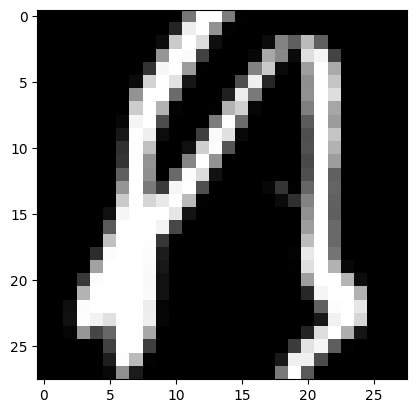

In [ ]:
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [66]:
y_train[0]

np.uint8(8)

# 4. Prepare Data

[4.1] Reshape the images from the training and testing set to have the channel dimension last. The dimensions should be: (row_number, height, width, channel)

In [67]:
x_train.shape

(60000, 28, 28)

In [ ]:

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [69]:
x_train.shape

(60000, 28, 28, 1)

In [70]:
x_test.shape

(10000, 28, 28, 1)

[4.2]Cast `x_train` and `x_test` into `float32` decimals

In [71]:
x_train.dtype

dtype('uint8')

In [ ]:

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

In [73]:
x_train.dtype

dtype('float32')

In [74]:
x_test.dtype

dtype('float32')

[4.3] Standardise the images of the training and testing sets. Originally each image contains pixels with value ranging from 0 to 255. after standardisation, the new value range should be from 0 to 1.

In [ ]:

x_train = x_train / 255.0
x_test = x_test / 255.0

In [76]:
print("Min pixel value:", np.min(x_train))  # Should be 0.0
print("Max pixel value:", np.max(x_train))  # Should be 1.0
print("Data type:", x_train.dtype)  # Should remain float

Min pixel value: 0.0
Max pixel value: 1.0
Data type: float32


[4.4] Create a variable called `num_classes` that will take the value 10 which corresponds to the number of classes for the target variable

In [ ]:
num_classes = 10

[4.5] Convert the target variable for the training and testing sets to a binary class matrix of dimension (rows, num_classes).

For example:
- class 0 will become [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
- class 1 will become [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
- class 5 will become [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
- class 9 will become [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [78]:
y_train

array([8, 7, 0, ..., 0, 4, 9], dtype=uint8)

In [79]:
# Test out np.eye
np.eye(10)[y_train]

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:

y_train = np.eye(num_classes)[y_train]
y_test = np.eye(num_classes)[y_test]

In [81]:
print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


In [82]:
from torch.utils.data import TensorDataset, DataLoader

In [83]:
x_train.dtype

dtype('float32')

In [84]:
y_train

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [85]:
y_test

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [86]:
# Create a variable called `device` that will automatically select a GPU if available. Otherwise it will default to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [87]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device = device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device = device)

In [88]:
X_test_tensor = torch.tensor(x_test, dtype=torch.float32, device = device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device = device)

In [89]:
# Ensure the sizes match
print("x_train shape:", x_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)


x_train shape: torch.Size([60000, 28, 28, 1])
y_train shape: torch.Size([60000, 10])


In [90]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

In [91]:
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 5. Define Neural Networks Architecture

[5.1] Set the seed in PyTorch for reproducing results



In [ ]:
torch.manual_seed(0)

[5.2] Define the architecture of your Neural Networks and save it into a variable called `model`

Soft Max is used as an activation function for multi-class problem

In [ ]:
class MLP(nn.Module):    # Creating a class called MLP that inherits nn.Module
  def __init__(self, input_size, hidden_size, output_size):    # Initialize the class
      super(MLP,self).__init__()
      self.fc1 = nn.Linear(input_size,hidden_size) # Fully connected Layer1 (Input to hidden layer)
      self.relu = nn.ReLU() # Calling Rectified Linear Unit
      self.dropout = nn.Dropout(0.5)
      self.fc2 = nn.Linear(hidden_size,output_size) # Fully connected Layer2 (Hidden to output layer)

  def forward(self,x):
    x = x.view(x.size(0), -1) # Flatten image
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    return x


In [94]:
input_size = 28*28
hidden_size = 128
output_size = 10

In [95]:
model = MLP(input_size, hidden_size, output_size).to(device)

[5.2] Print the summary of your model

In [ ]:
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# 6. Train Neural Networks

[6.1] Create 2 variables called `batch_size` and `epochs` that will  respectively take the values 128 and 500

In [ ]:
batch_size = 128
epochs = 500

[6.2] Compile your model with the appropriate loss function, the optimiser of your choice and the accuracy metric

In [ ]:
# Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()  # For multi-class classification

def compute_accuracy(output,label):
  prediction = torch.argmax(output, dim=1)
  total_correct = (prediction == label).sum().item()
  accuracy = total_correct / len(label)
  return accuracy

Rationale for the accuracy matrix:
***prediction = torch.argmax(output, dim=1)*** will gives you the class index with the highest probability. dim=1 will output the max (i.e predicted class = 5). Then we calculate accuracy based on the number predicted correctly.


[6.3] Train your model
using the number of epochs defined. Calculate the total loss and save it to a variable called total_loss.

In [99]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # The training data is shuffled each epoch, which helps with model generalization.

In [100]:
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # The test data is not shuffled, ensuring consistent evaluation.

In [ ]:

losses = []             # List to store individual batch losses
epoch_losses = []       # Average loss per epoch for training
total_loss = []         # Total loss for training
train_accuracies = []   # Training accuracy per epoch

for epoch in range(epochs):
  model.train()       # Set the model to training model
  loss_count = 0      # Accumulate training loss for the current epoch
  total_correct=0     # Count correct prediction in training
  total_train = 0   # Total number of training sample produced

  for images, labels in train_dataloader:
    images, labels = images.to(device), labels.to(device)   # Move to GPU if available

    predicted_output = model(images)   # Forward Propagation to get predicted outcome
    loss = criterion(predicted_output, labels)   # Calculate the loss
    losses.append(loss.detach().cpu().numpy())      # Keep track of the loss

    optimizer.zero_grad()     # Reset gradient
    loss.backward()           # Backpropagation
    optimizer.step()          # Update weights

    # Track loss and accuracy
    loss_count += loss.item()     # Accumulate training loss
    _, predicted = torch.max(predicted_output, 1)
    total_train += labels.size(0)
    total_correct += (predicted == labels.argmax(dim=1)).sum().item()

  total_loss.append(loss_count)   # Calculate the total loss and save it to a variable called total_loss
  epoch_losses.append (loss_count/len(train_dataloader))  # Append the training loss
  train_accuracies.append(total_correct / total_train)    # Append the training accuracy


  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_losses[-1]:.4f}, Total loss: {total_loss[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}")

Epoch 1/500, Train Loss: 0.7497, Total loss: 351.5865, Train Accuracy: 0.7764
Epoch 2/500, Train Loss: 0.4604, Total loss: 215.9050, Train Accuracy: 0.8604
Epoch 3/500, Train Loss: 0.3888, Total loss: 182.3606, Train Accuracy: 0.8827
Epoch 4/500, Train Loss: 0.3536, Total loss: 165.8576, Train Accuracy: 0.8934
Epoch 5/500, Train Loss: 0.3275, Total loss: 153.5896, Train Accuracy: 0.9010
Epoch 6/500, Train Loss: 0.3108, Total loss: 145.7870, Train Accuracy: 0.9043
Epoch 7/500, Train Loss: 0.2945, Total loss: 138.1312, Train Accuracy: 0.9094
Epoch 8/500, Train Loss: 0.2888, Total loss: 135.4586, Train Accuracy: 0.9120
Epoch 9/500, Train Loss: 0.2716, Total loss: 127.3607, Train Accuracy: 0.9159
Epoch 10/500, Train Loss: 0.2679, Total loss: 125.6386, Train Accuracy: 0.9166
Epoch 11/500, Train Loss: 0.2616, Total loss: 122.7065, Train Accuracy: 0.9193
Epoch 12/500, Train Loss: 0.2535, Total loss: 118.9031, Train Accuracy: 0.9210
Epoch 13/500, Train Loss: 0.2452, Total loss: 115.0025, Train

[6.4]Test your model.  Initiate the model.eval() along with torch.no_grad() to turn off the gradients.


In [ ]:
model.eval()
correct = 0
total = 0

# Get the predictions for the test dataset
predicted_labels = []
true_labels = []

with torch.no_grad():
  for images, labels in test_dataloader:
    images, labels = images.to(device), labels.to(device) # Switch to GPU if available

    outputs = model(images)
    predicted = torch.max(outputs, 1)[1]  # Determine predicted classes
    total += labels.size(0)
    correct += (predicted == labels.argmax(dim=1)).sum().item()
    predicted_labels.extend(predicted.tolist())
    true_labels.extend(labels.argmax(dim=1).tolist())


In [52]:
accuracy = correct / total
print(f"Accuracy on the test set: {accuracy:.2%}")

Accuracy on the test set: 84.18%


# 7. Analyse Results

[7.1] Display the performance of your model on the training and testing sets

In [ ]:
print(f"Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Train Accuracy: 0.9710
Test Accuracy: 0.8418


The model overfits

[7.2] Plot the learning curve of your model

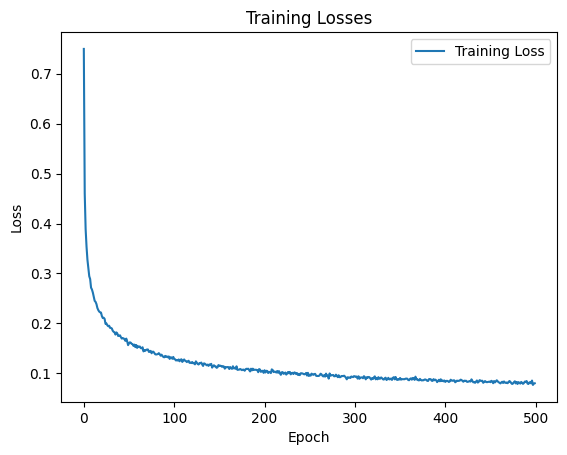

In [ ]:
plt.plot(epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.show()

[7.3] Display the confusion matrix on the testing set predictions

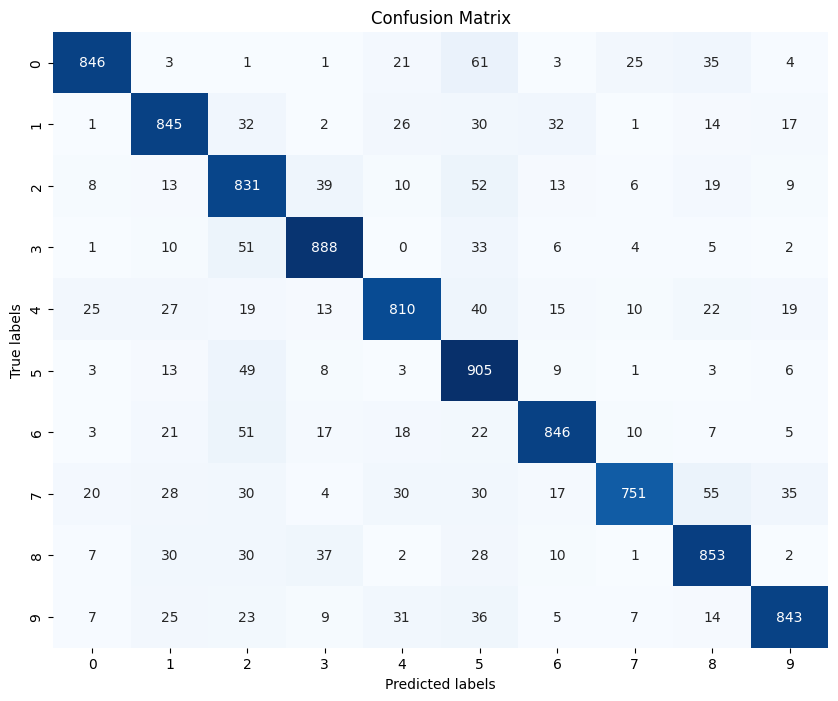

In [ ]:
# Import the packages for plotting the graph
import seaborn as sns
from sklearn.metrics import confusion_matrix


conf_matrix = confusion_matrix(true_labels, predicted_labels)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Data Spliting:

To assess overfitting we will seperate the training dataset into  validation with 80/20 train validation split.

In [110]:
from sklearn.model_selection import train_test_split

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

In [111]:
# Convert to PyTorch tensors
train_data = TensorDataset(torch.tensor(x_train_split).float(), torch.tensor(y_train_split).long())
val_data = TensorDataset(torch.tensor(x_val_split).float(), torch.tensor(y_val_split).long())

In [116]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False) # The test data is not shuffled, ensuring consistent evaluation.

In [117]:
# Check to see if format is correct

for images, labels in train_loader:
    print("Training labels:", labels[:5], labels.dtype, labels.shape)
    break

for images, labels in val_loader:
    print("Validation labels:", labels[:5], labels.dtype, labels.shape)
    break

Training labels: tensor([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]]) torch.int64 torch.Size([128, 10])
Validation labels: tensor([[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]]) torch.int64 torch.Size([128, 10])


# 8. Experiment 1:

## 8.1 Define Neural Network Architecture

In this architecture we will:


*   Add another fully connected layer
*   Increase hidden size to 512
*  Use batch normalization to stabalize learning process nad speed up convergence








In [61]:
input_size = 28*28
hidden_size = 512
output_size = 10

In [62]:
batch_size = 128
epochs = 500

In [63]:
class MLP_2(nn.Module):    # Creating a class called MLP that inherits nn.Module
  def __init__(self, input_size, hidden_size, output_size):    # Initialize the class
      super(MLP_2,self).__init__()

      # First hidden layer
      self.fc1 = nn.Linear(input_size,hidden_size) # Fully connected Layer1 (Input to hidden layer)
      self.dropout = nn.Dropout(0.5)
      self.batch_norm = nn.BatchNorm1d(hidden_size) # Batch Normalization

      # Second hidden layer
      self.fc2 = nn.Linear(hidden_size,hidden_size) # Fully connected Layer2

      # Output layer
      self.fc3 = nn.Linear(hidden_size, output_size) # Fully connected Layer3 (to output)

      self.relu = nn.ReLU() # Calling Rectified Linear Unit

  def forward(self,x):
    x = x.view(x.size(0), -1) # Flatten image

    # 1st hidden layer
    x = self.fc1(x)
    x = self.batch_norm(x) # Apply batch normalization
    x = self.relu(x)
    x = self.dropout(x)

    # 2nd hidden layer
    x = self.fc2(x)
    x = self.relu(x)

    # Output layer
    x = self.fc3(x)
    return x


## 8.2 Model Training

In [64]:
model_2 = MLP_2(input_size, hidden_size, output_size).to(device)

In [65]:
print(model_2)

MLP_2(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


In [66]:
optimizer = optim.Adam(model_2.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()  # For multi-class classification


The model kept getting stuck at a global minima. After the 5th iteration we adjust the learning rate and got signiificantly better results.

In [67]:
losses = []             # List to store individual batch losses
epoch_losses = []       # Average loss per epoch for training
total_loss = []         # Total loss for training
train_accuracies = []   # Training accuracy per epoch
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

for epoch in range(epochs):
    # Training Phase
    model_2.train()       # Set the model to training mode
    loss_count = 0      # Accumulate training loss for the current epoch
    total_correct = 0   # Count correct predictions in training
    total_train = 0     # Total number of training samples

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move to GPU if available

        predicted_output = model_2(images)   # Forward Propagation to get predicted outcome
        loss = criterion(predicted_output, labels.argmax(dim=1))   # Calculate the loss
        losses.append(loss.detach().cpu().numpy())  # Keep track of the loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        # Track loss and accuracy
        loss_count += loss.item()  # Accumulate training loss
        _, predicted = torch.max(predicted_output, 1)
        total_train += labels.size(0)
        total_correct += (predicted == labels.argmax(dim=1)).sum().item()

    total_loss.append(loss_count)  # Store the total loss
    epoch_losses.append(loss_count / len(train_loader))  # Store the average training loss
    train_accuracies.append(total_correct / total_train)  # Store the training accuracy

    # Validation Phase
    val_loss_count = 0  # Accumulate validation loss
    val_correct = 0     # Count correct predictions in validation
    val_total = 0       # Total number of validation samples

    with torch.no_grad():  # No need to compute gradients for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move to GPU if available

            predicted_output = model_2(images)  # Forward Propagation for validation
            val_loss = criterion(predicted_output, labels.argmax(dim=1))  # Validation loss

            val_loss_count += val_loss.item()  # Accumulate validation loss

            _, predicted = torch.max(predicted_output, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels.argmax(dim=1)).sum().item()

    val_losses.append(val_loss_count / len(val_loader))  # Store total validation loss
    val_accuracies.append(val_correct / val_total)  # Store validation accuracy

    # Print metrics
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {epoch_losses[-1]:.4f}, Total Loss: {total_loss[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}, "
          f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")


Epoch 1/500, Train Loss: 0.4866, Total Loss: 182.4661, Train Accuracy: 0.8496, Validation Loss: 0.3387, Validation Accuracy: 0.8968
Epoch 2/500, Train Loss: 0.2839, Total Loss: 106.4548, Train Accuracy: 0.9143, Validation Loss: 0.2835, Validation Accuracy: 0.9127
Epoch 3/500, Train Loss: 0.2343, Total Loss: 87.8697, Train Accuracy: 0.9294, Validation Loss: 0.2573, Validation Accuracy: 0.9229
Epoch 4/500, Train Loss: 0.2032, Total Loss: 76.1835, Train Accuracy: 0.9375, Validation Loss: 0.2529, Validation Accuracy: 0.9271
Epoch 5/500, Train Loss: 0.1851, Total Loss: 69.3963, Train Accuracy: 0.9425, Validation Loss: 0.2372, Validation Accuracy: 0.9303
Epoch 6/500, Train Loss: 0.1744, Total Loss: 65.4089, Train Accuracy: 0.9457, Validation Loss: 0.2482, Validation Accuracy: 0.9343
Epoch 7/500, Train Loss: 0.1676, Total Loss: 62.8535, Train Accuracy: 0.9476, Validation Loss: 0.2655, Validation Accuracy: 0.9261
Epoch 8/500, Train Loss: 0.1605, Total Loss: 60.1922, Train Accuracy: 0.9512, Val

## 8.3 Model Evaluation

In [68]:
model_2.eval()
correct = 0
total = 0

# Get the predictions for the test dataset
predicted_labels = []
true_labels = []

with torch.no_grad():
  for images, labels in test_dataloader:
    images, labels = images.to(device), labels.to(device) # Switch to GPU if available

    outputs = model_2(images)
    predicted = torch.max(outputs, 1)[1]  # Determine predicted classes
    total += labels.size(0)
    correct += (predicted == labels.argmax(dim=1)).sum().item()
    predicted_labels.extend(predicted.tolist())
    true_labels.extend(labels.argmax(dim=1).tolist())


In [69]:
accuracy = correct / total
print(f"Accuracy on the test set: {accuracy:.2%}")

Accuracy on the test set: 90.50%


In [70]:
print(f"Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Train Accuracy: 0.9887
Validation Accuracy: 0.9457
Test Accuracy: 0.9050


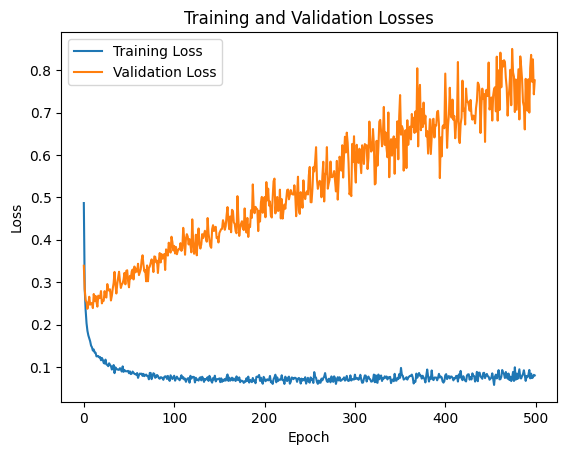

In [71]:
# Plot training and validation loss

plt.plot(epoch_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

Key results:


*  The model performs significantly better than the first model
*  The model exhibits signs of overfitting as indicated by the train/validation loss graph and the relatively poorer performance on the testing set.

Next experiment will look into reducing overfitting by
*   lowering number of hidden connection
*   at L2 weight decay in Adam optimizer
*   From the graph above, between 50-100 epoch the model no longer improve much so we can try reducing number of epoch as well.







# 9. Experiment 2:

## 9.1 Define Neural Network Architecture

In this NN architecture we will

*   reduce number of neurons connection in hidden layer 2 from 512 -> 256
*   Add L2 weight decay to Adam optimizer
*   Add batch norm to layer 2
*   Depending on output of the training lower epochs




In [72]:
input_size = 28*28
hidden_size_1 = 256
hidden_size_2 = 128
output_size = 10

In [74]:
class MLP_3(nn.Module):    # Creating a class called MLP that inherits nn.Module
  def __init__(self, input_size, hidden_size_1,hidden_size_2, output_size):    # Initialize the class
      super(MLP_3,self).__init__()
      # First Hidden Layer
      self.fc1 = nn.Linear(input_size,hidden_size_1) # Fully connected Layer1 (Input to hidden layer)
      self.batch_norm = nn.BatchNorm1d(hidden_size_1) # Batch Normalization
      self.dropout = nn.Dropout(0.5)


      # Second Hidden layer
      self.fc2 = nn.Linear(hidden_size_1,hidden_size_2) # Fully connected Layer2
      self.batch_norm2 = nn.BatchNorm1d(hidden_size_2)

      # Output layer
      self.fc3 = nn.Linear(hidden_size_2, output_size) # Fully connected Layer3 (to output)

      # Non-linearity
      self.relu = nn.ReLU() # Calling Rectified Linear Unit

  def forward(self,x):
    x = x.view(x.size(0), -1) # Flatten image

    # 1st hidden layer
    x = self.fc1(x)
    x = self.batch_norm(x) # Apply batch normalization
    x = self.relu(x)
    x = self.dropout(x)

    # 2nd hidden layer
    x = self.fc2(x)
    x = self.batch_norm2(x)
    x = self.relu(x)

    # Output layer
    x = self.fc3(x)
    return x

In [75]:
model_3 = MLP_3(input_size, hidden_size_1, hidden_size_2, output_size).to(device)

In [76]:
print(model_3)

MLP_3(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (batch_norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [77]:
optimizer = optim.Adam(model_3.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()  # For multi-class classification

## 9.2 Model Training

Note during training:


*  After 40 epochs no longer improve
*   Decrease leanrning rate from 0.01 -> 0.001, After 50 epochs no longer improve but overall result for both set is better

Reduce first connected layer 512 -> 256

*   After 30 epochs or so start overfitting on training set

Reduce hidden_size 2 from 256 -> 128

*   Increased leanrning rate from 0.001 -> 0.01, Overall less overfitting
*   Epoch can be lowered because no improvement after 10 to 20 epochs

Overall, consistent reult for both training and validation. Meet the target of above 80% accuracy








In [78]:
losses = []             # List to store individual batch losses
epoch_losses = []       # Average loss per epoch for training
total_loss = []         # Total loss for training
train_accuracies = []   # Training accuracy per epoch
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

for epoch in range(epochs):
    # Training Phase
    model_3.train()       # Set the model to training mode
    loss_count = 0      # Accumulate training loss for the current epoch
    total_correct = 0   # Count correct predictions in training
    total_train = 0     # Total number of training samples

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move to GPU if available

        predicted_output = model_3(images)   # Forward Propagation to get predicted outcome
        loss = criterion(predicted_output, labels.argmax(dim=1))   # Calculate the loss
        losses.append(loss.detach().cpu().numpy())  # Keep track of the loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        # Track loss and accuracy
        loss_count += loss.item()  # Accumulate training loss
        _, predicted = torch.max(predicted_output, 1)
        total_train += labels.size(0)
        total_correct += (predicted == labels.argmax(dim=1)).sum().item()

    total_loss.append(loss_count)  # Store the total loss
    epoch_losses.append(loss_count / len(train_loader))  # Store the average training loss
    train_accuracies.append(total_correct / total_train)  # Store the training accuracy

    # Validation Phase
    val_loss_count = 0  # Accumulate validation loss
    val_correct = 0     # Count correct predictions in validation
    val_total = 0       # Total number of validation samples

    with torch.no_grad():  # No need to compute gradients for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move to GPU if available

            predicted_output = model_3(images)  # Forward Propagation for validation
            val_loss = criterion(predicted_output, labels.argmax(dim=1))  # Validation loss

            val_loss_count += val_loss.item()  # Accumulate validation loss

            _, predicted = torch.max(predicted_output, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels.argmax(dim=1)).sum().item()

    val_losses.append(val_loss_count / len(val_loader))  # Store total validation loss
    val_accuracies.append(val_correct / val_total)  # Store validation accuracy

    # Print metrics
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {epoch_losses[-1]:.4f}, Total Loss: {total_loss[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}, "
          f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")


Epoch 1/500, Train Loss: 0.5107, Total Loss: 191.5277, Train Accuracy: 0.8381, Validation Loss: 0.3750, Validation Accuracy: 0.8787
Epoch 2/500, Train Loss: 0.3566, Total Loss: 133.7086, Train Accuracy: 0.8882, Validation Loss: 0.3668, Validation Accuracy: 0.8841
Epoch 3/500, Train Loss: 0.3371, Total Loss: 126.4063, Train Accuracy: 0.8937, Validation Loss: 0.3354, Validation Accuracy: 0.8938
Epoch 4/500, Train Loss: 0.3245, Total Loss: 121.6975, Train Accuracy: 0.8964, Validation Loss: 0.3442, Validation Accuracy: 0.8938
Epoch 5/500, Train Loss: 0.3217, Total Loss: 120.6377, Train Accuracy: 0.8976, Validation Loss: 0.3343, Validation Accuracy: 0.8914
Epoch 6/500, Train Loss: 0.3212, Total Loss: 120.4585, Train Accuracy: 0.8980, Validation Loss: 0.3408, Validation Accuracy: 0.8942
Epoch 7/500, Train Loss: 0.3137, Total Loss: 117.6346, Train Accuracy: 0.9000, Validation Loss: 0.3426, Validation Accuracy: 0.8912
Epoch 8/500, Train Loss: 0.3161, Total Loss: 118.5558, Train Accuracy: 0.899

## 9.3 Model Evaluation

In [79]:
model_3.eval()
correct = 0
total = 0

# Get the predictions for the test dataset
predicted_labels = []
true_labels = []

with torch.no_grad():
  for images, labels in test_dataloader:
    images, labels = images.to(device), labels.to(device) # Switch to GPU if available

    outputs = model_3(images)
    predicted = torch.max(outputs, 1)[1]  # Determine predicted classes
    total += labels.size(0)
    correct += (predicted == labels.argmax(dim=1)).sum().item()
    predicted_labels.extend(predicted.tolist())
    true_labels.extend(labels.argmax(dim=1).tolist())


In [80]:
accuracy = correct / total
print(f"Accuracy on the test set: {accuracy:.2%}")

Accuracy on the test set: 86.43%


In [81]:
print(f"Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Train Accuracy: 0.9042
Validation Accuracy: 0.8986
Test Accuracy: 0.8643


The model slightly overfit on training and validation. This indicate that there is room to improve model generalizabilityindicates. Perhaps introducing early stoppage.

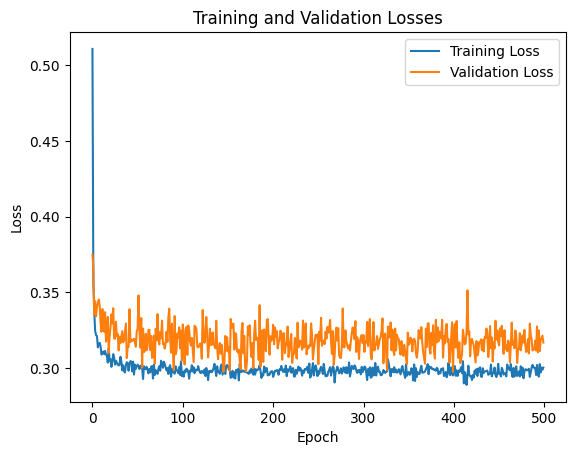

In [82]:
# Plot training and validation loss

plt.plot(epoch_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

The graph above indicate instability in validation data:
1. Training Loss (blue) is relatively stable around ~0.29–0.31.
2. Validation Loss (orange) is consistently higher and fluctuates more (~0.31–0.36).

Could be due to insufficient regularization, a learning rate that’s slightly off, or a small validation set causing noisy estimates of loss.
Since testing performance is also relatively poorer, it seems the model still does not generalize very well.

For next experiment:

*   Lower learning rate
*   Reduce number of epoch to 50, because evidence through above graph indicate convergence occuring around those epochs
*   Add another dropout layer in fc2 to regularize the second hidden layer







# 10. Experiment 3:

## 10.1 Define Neural Network Architecture

*   Lower learning rate to 0.001 or 0.0005
*   Reduce number of epoch to 50
*   Increase dropout rate 0.5 -> 0.6
*   Add another dropout layer in fc2 to regularize the second hidden layer


In [127]:
input_size = 28*28
hidden_size_1 = 256
hidden_size_2 = 200
output_size = 10

In [128]:
batch_size = 128
epochs = 20

In [129]:
class MLP_4(nn.Module):    # Creating a class called MLP that inherits nn.Module
  def __init__(self, input_size, hidden_size_1,hidden_size_2, output_size):    # Initialize the class
      super(MLP_4,self).__init__()

      # First hideen layer
      self.fc1 = nn.Linear(input_size,hidden_size_1) # Fully connected Layer1 (Input to hidden layer)
      self.batch_norm = nn.BatchNorm1d(hidden_size_1) # Batch Normalization
      self.dropout = nn.Dropout(0.8)

      # Second hidden layer
      self.fc2 = nn.Linear(hidden_size_1,hidden_size_2) # Fully connected Layer2
      self.batch_norm2 = nn.BatchNorm1d(hidden_size_2)
      self.dropout_2 = nn.Dropout(0.6)

      # Output layer
      self.fc3 = nn.Linear(hidden_size_2, output_size) # Fully connected Layer3 (to output)

      # Calling Rectified Linear Unit
      self.relu = nn.ReLU()


  def forward(self,x):
    x = x.view(x.size(0), -1) # Flatten image

    # 1st Layer
    x = self.fc1(x)
    x = self.batch_norm(x) # Apply batch normalization
    x = self.relu(x)
    x = self.dropout(x)

    # 2nd layer
    x = self.fc2(x)
    x = self.relu(x)
    x = self.batch_norm2(x) # Apply batch normalization
    x = self.dropout_2(x)

    # Output layer
    x = self.fc3(x)
    return x

In [130]:
model_4 = MLP_4(input_size, hidden_size_1, hidden_size_2, output_size).to(device)

In [131]:
print(model_4)

MLP_4(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.8, inplace=False)
  (fc2): Linear(in_features=256, out_features=200, bias=True)
  (batch_norm2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout_2): Dropout(p=0.6, inplace=False)
  (fc3): Linear(in_features=200, out_features=10, bias=True)
  (relu): ReLU()
)


In [132]:
optimizer = optim.Adam(model_4.parameters(), lr=0.001, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()  # For multi-class classification

## 10.2 Model Training

Notes during training:
*   The model overfits after around 5 epochs
*   Try reducing hidden_layer1 size 256 -> 128 (the model perform very poorly)

Try a different optimizer SGD with momentum
*   Overfit persist, and convergence is slower than ADAM

Try reducing hidden_layer2 size 128 -> 64
*   Poorer performance overall but better generalizability

Try increasing hidden_layer2 64 -> 84
*  Epoch are reduced to 25 as model no longer improved

Try increasing hidden_layer2 64 -> 84 and increase dropout rate layer_2 0.6 -> 0.8

*   Change dropout rate for layer_1 0.6->0.8  improve overfitting


Try get a better performance by increasing hidden_layer2 and adding more epoch to see if train and val loss diverge or not
*   Best low overfitting result so far

Try increase hidden_layer2 126 -> 256


Stop experimenting here since target is met and overfitting is satisfactgory




In [133]:
losses = []             # List to store individual batch losses
epoch_losses = []       # Average loss per epoch for training
total_loss = []         # Total loss for training
train_accuracies = []   # Training accuracy per epoch
val_losses = []         # List to store validation losses
val_accuracies = []     # List to store validation accuracies

for epoch in range(epochs):
    # Training Phase
    model_4.train()       # Set the model to training mode
    loss_count = 0      # Accumulate training loss for the current epoch
    total_correct = 0   # Count correct predictions in training
    total_train = 0     # Total number of training samples

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move to GPU if available

        predicted_output = model_4(images)   # Forward Propagation to get predicted outcome
        loss = criterion(predicted_output, labels.argmax(dim=1))   # Calculate the loss
        losses.append(loss.detach().cpu().numpy())  # Keep track of the loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        # Track loss and accuracy
        loss_count += loss.item()  # Accumulate training loss
        _, predicted = torch.max(predicted_output, 1)
        total_train += labels.size(0)
        total_correct += (predicted == labels.argmax(dim=1)).sum().item()

    total_loss.append(loss_count)  # Store the total loss
    epoch_losses.append(loss_count / len(train_loader))  # Store the average training loss
    train_accuracies.append(total_correct / total_train)  # Store the training accuracy

    # Validation Phase
    val_loss_count = 0  # Accumulate validation loss
    val_correct = 0     # Count correct predictions in validation
    val_total = 0       # Total number of validation samples

    with torch.no_grad():  # No need to compute gradients for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)  # Move to GPU if available

            predicted_output = model_4(images)  # Forward Propagation for validation
            val_loss = criterion(predicted_output, labels.argmax(dim=1))  # Validation loss

            val_loss_count += val_loss.item()  # Accumulate validation loss

            _, predicted = torch.max(predicted_output, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels.argmax(dim=1)).sum().item()

    val_losses.append(val_loss_count / len(val_loader))  # Store total validation loss
    val_accuracies.append(val_correct / val_total)  # Store validation accuracy

    # Print metrics
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {epoch_losses[-1]:.4f}, Total Loss: {total_loss[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}, "
          f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accuracies[-1]:.4f}")


Epoch 1/20, Train Loss: 1.0675, Total Loss: 400.3258, Train Accuracy: 0.6562, Validation Loss: 0.8231, Validation Accuracy: 0.7397
Epoch 2/20, Train Loss: 0.7593, Total Loss: 284.7484, Train Accuracy: 0.7611, Validation Loss: 0.7291, Validation Accuracy: 0.7713
Epoch 3/20, Train Loss: 0.6913, Total Loss: 259.2496, Train Accuracy: 0.7838, Validation Loss: 0.6703, Validation Accuracy: 0.7917
Epoch 4/20, Train Loss: 0.6371, Total Loss: 238.9245, Train Accuracy: 0.7979, Validation Loss: 0.6338, Validation Accuracy: 0.8055
Epoch 5/20, Train Loss: 0.6023, Total Loss: 225.8713, Train Accuracy: 0.8093, Validation Loss: 0.6238, Validation Accuracy: 0.8070
Epoch 6/20, Train Loss: 0.5796, Total Loss: 217.3430, Train Accuracy: 0.8207, Validation Loss: 0.5961, Validation Accuracy: 0.8143
Epoch 7/20, Train Loss: 0.5571, Total Loss: 208.9109, Train Accuracy: 0.8258, Validation Loss: 0.5853, Validation Accuracy: 0.8183
Epoch 8/20, Train Loss: 0.5378, Total Loss: 201.6615, Train Accuracy: 0.8326, Valid

In [90]:
# Save model
torch.save(model_4.state_dict(), "fourth_model.pth")

## 10.3 Model Evaluation

In [91]:
# Load architecture before weight
# model_4 = MLP_4(input_size, hidden_size_1, hidden_size_2, output_size).to(device)

In [92]:
# 2. Load the state_dict
# model_4.load_state_dict(torch.load("fourth_model.pth"))

In [134]:
model_4.eval()
correct = 0
total = 0

# Get the predictions for the test dataset
predicted_labels = []
true_labels = []

with torch.no_grad():
  for images, labels in test_dataloader:
    images, labels = images.to(device), labels.to(device) # Switch to GPU if available

    outputs = model_4(images)
    predicted = torch.max(outputs, 1)[1]  # Determine predicted classes
    total += labels.size(0)
    correct += (predicted == labels.argmax(dim=1)).sum().item()
    predicted_labels.extend(predicted.tolist())
    true_labels.extend(labels.argmax(dim=1).tolist())


In [135]:
accuracy = correct / total
print(f"Accuracy on the test set: {accuracy:.2%}")

Accuracy on the test set: 83.41%


In [136]:
print(f"Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Train Accuracy: 0.8571
Validation Accuracy: 0.8376
Test Accuracy: 0.8341


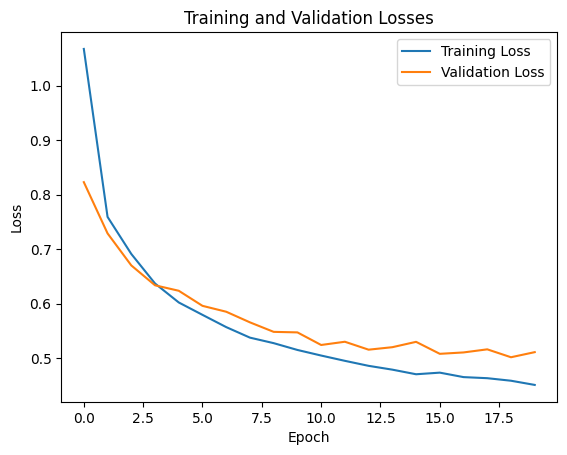

In [137]:
# Plot training and validation loss

plt.plot(epoch_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

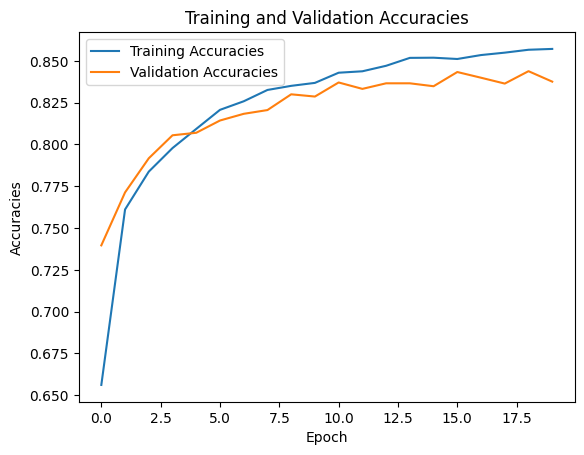

In [138]:
# Plot training and validation accuracies
plt.plot(train_accuracies, label='Training Accuracies')
plt.plot(val_accuracies, label='Validation Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracies')
plt.title('Training and Validation Accuracies')
plt.legend()
plt.show()

In [139]:
# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

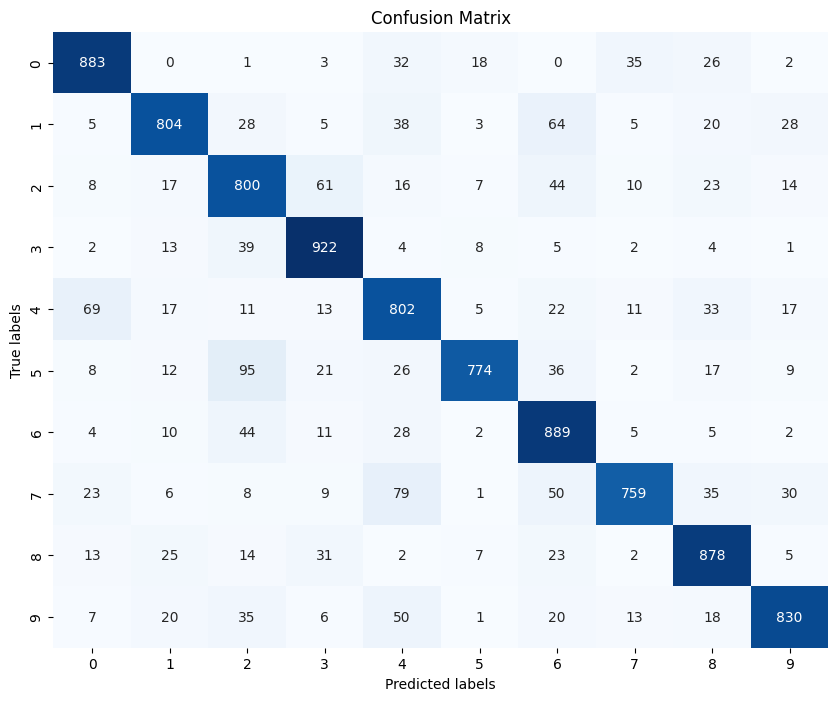

In [140]:

# Import the packages for plotting the graph
import seaborn as sns
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()